# Lecture 7: Harmonics



In [74]:
import numpy as np
import matplotlib.pyplot as plt
Fs = 8000
duration = 4000

## 1. Creating a synthetic vowel

Vowels are periodic sounds created by taking any periodic signal (with period $T_0=\frac{1}{F_0}$), and passing it through [resonators](https://en.wikipedia.org/wiki/Resonance) with [formant frequencies that define the vowel](https://en.wikipedia.org/wiki/Formant).  A resonator is a system with two feedback connections, as shown below:

In [78]:
def resonator(x,F,BW,Fs):
    C = -np.exp(-2*np.pi*BW/Fs)
    B = 2 * np.exp(-np.pi*BW/Fs) * np.cos(2*np.pi*F/Fs)
    A = 1 - B - C
    y = np.zeros(len(x))
    y[0] = A*x[0]
    y[1] = A*x[1] + B*y[0]
    for n in range(2,len(y)):
        y[n] = A*x[n] + B*y[n-1] + C*y[n-2]
    return y

* The excitation signal $e[n]$ has one sample per period equal to 1, all others equal zero.
* A reasonable pitch period is 0.01s (100Hz) = 80 samples at $F_s=8000$.
* Then we pass the excitation through resonators with F1 and F2 as given in [wikipedia](https://en.wikipedia.org/wiki/Formant) for the vowel we want.
* For the higher formants and bandwidths, we'll use some neutral default values that don't depend on the vowel.

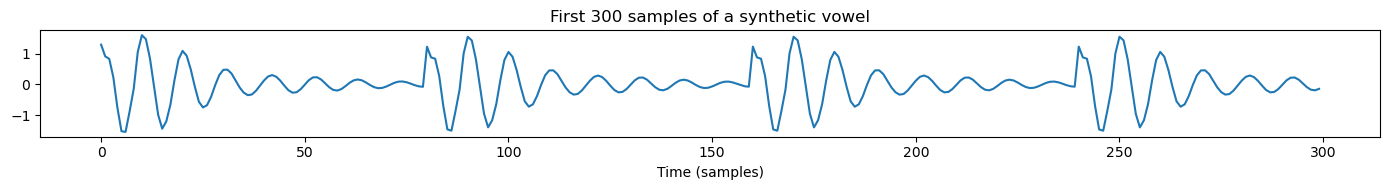

In [79]:
F0 = 100
T0 = int(np.round(Fs/F0))
e = np.zeros(duration)
e[::T0] = 1

x1 = resonator(e,750,100,Fs)
x2 = resonator(x1,940,200,Fs)
x3 = resonator(x2,2500,300,Fs)
x4 = resonator(x3,3500,400,Fs)

fig = plt.figure(figsize=(14,2),layout='tight')
subplot = fig.subplots(1,1)
subplot.plot(x4[:300])
subplot.set_title('First 300 samples of a synthetic vowel')
subplot.set_xlabel('Time (samples)')

import IPython
IPython.display.Audio(data=x4, rate=Fs)


## 2. Fourier Synthesis of a Periodic Signal

Notice that, despite its complexity, this signal is perfectly periodic with a period of $T_0=80$ samples.

In 1822, [Joseph Fourier](https://en.wikipedia.org/wiki/Joseph_Fourier) proposed that any periodic signal, with a period of $T_0$, can be expressed as the sum of sinusoids at frequencies including all integer multiples of $\frac{1}{T_0}$.  We will write his proposal in the following form:

$$x[n] = \sum_{k} X_k e^{-j\frac{2\pi k n}{T_0}}$$

We will spend the next two lectures talking about the Fourier series coefficients, $X_k$.  For now, we can obtain them using [numpy.fft.fft](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html).  Let's analyze the vowel, and then resynthesize it, one harmonic at a time:

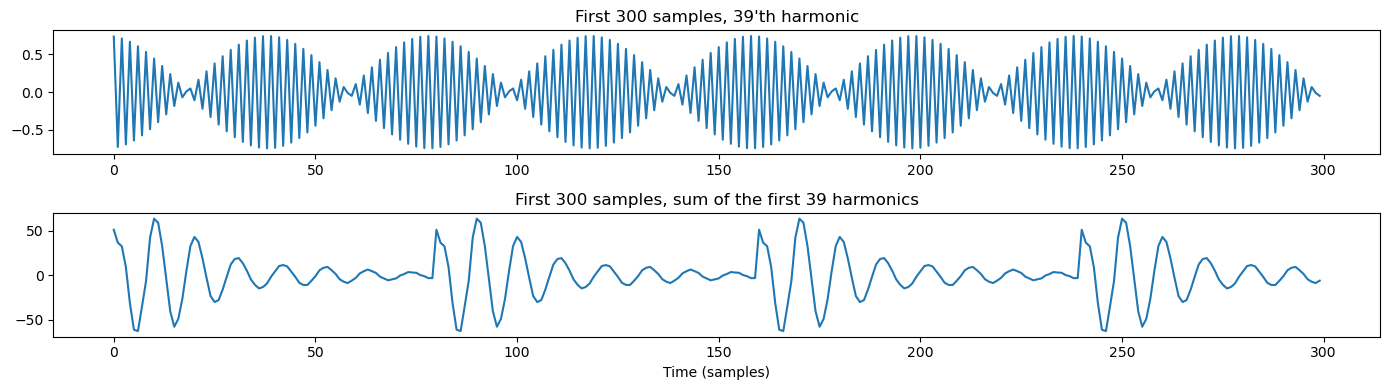

In [80]:
X = np.fft.fft(x4[:80])

n = np.arange(N)
harmonics = np.zeros((40,N))
for k in range(40):
    harmonics[k,:] = np.real(X[k]*np.exp(1j*2*np.pi*k*n/T0))

num_harmonics=39
synthesized = np.sum(harmonics[1:1+num_harmonics,:], axis=0)

fig = plt.figure(figsize=(14,4),layout='tight')
subplot = fig.subplots(2,1)
subplot[0].plot(harmonics[num_harmonics,:300])
subplot[0].set_title("First 300 samples, %d'th harmonic"%(num_harmonics))
subplot[1].plot(synthesized[:300])
subplot[1].set_title('First 300 samples, sum of the first %d harmonics'%(num_harmonics))
subplot[1].set_xlabel('Time (samples)')

import IPython
IPython.display.Audio(data=synthesized, rate=Fs)